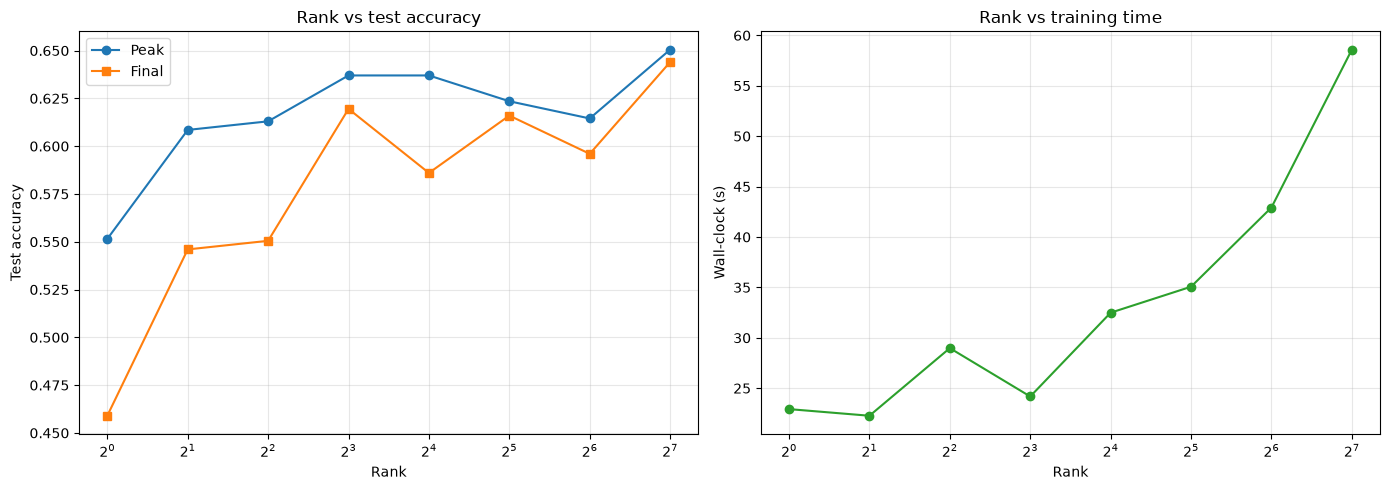

In [1]:
import json
import matplotlib.pyplot as plt

with open("/home/gagan/dissertation/eggroll-diss/results/rank_sweep.json") as f:
    data = json.load(f)
results = data   # the whole file IS the results dict

ranks = sorted(int(r) for r in results.keys())
peaks = [max(results[str(r)]["test_acc"]) for r in ranks]
finals = [results[str(r)]["test_acc"][-1] for r in ranks]
times = [results[str(r)]["wallclock"][-1] for r in ranks]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ranks, peaks, marker="o", label="Peak")
axes[0].plot(ranks, finals, marker="s", label="Final")
axes[0].set_xscale("log", base=2)
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Rank vs test accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ranks, times, marker="o", color="C2")
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("Rank")
axes[1].set_ylabel("Wall-clock (s)")
axes[1].set_title("Rank vs training time")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/home/gagan/dissertation/eggroll-diss/figures/rank_sweep.png", dpi=150)
plt.show()